# ViT-B/16 encrypted inference

We test ViT-B/16 most common inference as a service scenario: remote image classification. An image gets classified under CKKS on GPU. 
Only the patch embedding runs client-side. 

<!-- prereq-cell -->
> **Prerequisites.** This notebook loads artifacts it does not create: the exported
> weights (`weights.bin.zip`, `client.npz`), the calibrated `configs.json`, and, for the
> planned path, a bootstrap plan. Run **`setup_artifacts.ipynb`** first if you do not
> have them.

/leonardo_work/IscrC_eff-SAM2/azirilli/he-aware-training/.venv/lib/python3.11/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm



Loading weights:   0%|          | 0/200 [00:00<?, ?it/s]


Loading weights: 100%|██████████| 200/200 [00:00<00:00, 11437.35it/s]

image 0: (1, 3, 112, 112)  (res=112)


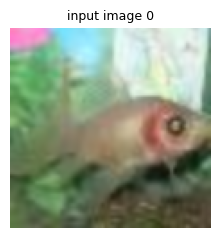

In [ ]:
import os, time

import numpy as np
import torch                                   # torch before _core (NCCL load order)
import matplotlib.pyplot as plt
from transformers import AutoModelForImageClassification

from perseus import _core
from perseus.nn import EncViT

# ── pick the image here ───────────────────────────────────────────────────────
IMAGE_INDEX = 0          # index into the dataset
RES         = int(os.environ.get("GATE_RES", "112"))
# ──────────────────────────────────────────────────────────────────────────────

k = int(os.environ.get("GATE_BLOCKS", "12"))
model_name = os.environ.get("VIT_MODEL", "google/vit-base-patch16-224") # use the hugging face string.
model_dir = os.environ["VIT_MODEL_DIR"]

hf = AutoModelForImageClassification.from_pretrained(
    model_name, attn_implementation="eager").eval()

pool = np.load(os.environ["VIT_POOL"], mmap_mode="r")
pix = torch.from_numpy(np.stack([pool[IMAGE_INDEX]]))
pix = torch.nn.functional.interpolate(pix, size=(RES, RES), mode="bilinear", antialias=True) # we interpolate to a number of patches that
                                                                                        # fit a single ciphertext
print(f"image {IMAGE_INDEX}: {tuple(pix.shape)}  (res={RES})")


def show(t, title):
    """Processor tensors are normalised to [-1, 1]; undo that for display."""
    img = ((t[0].permute(1, 2, 0).numpy() + 1) / 2).clip(0, 1)
    plt.figure(figsize=(2.6, 2.6)); plt.imshow(img); plt.axis("off")
    plt.title(title, fontsize=9); plt.show()


show(pix, f"input image {IMAGE_INDEX}")

## Client side: patch embedding, 
then the plaintext reference for comparison

In [2]:
with torch.no_grad():
    emb = hf.vit.embeddings(pix, interpolate_pos_encoding=True)
    h = emb
    for b in range(k):
        out = hf.vit.encoder.layer[b](h)
        h = out[0] if isinstance(out, tuple) else out
    ref_logits = hf.classifier(hf.vit.layernorm(h)[0, 0]).numpy()

tokens = emb[0].numpy().tolist()
ref_id = int(np.argmax(ref_logits))
print(f"patch tokens : {len(tokens)} x {len(tokens[0])}")
print(f"plaintext top-1 = {ref_id} ({hf.config.id2label[ref_id]})")

patch tokens : 50 x 768
plaintext top-1 = 1 (goldfish, Carassius auratus)


## Build the encrypted model, encrypt the image

In [3]:
opts = _core.InferenceOptions()
opts.ckks = _core.CKKSOptions.from_env()
_mode = os.environ.get("VIT_MODE", "threaded")
opts.mode = {"sync": _core.InferenceMode.Sync,
             "threaded": _core.InferenceMode.Threaded}[_mode]
inf = _core.make_vit_inference(opts)

store = _core.WeightStore.from_zip(os.path.join(model_dir, "weights.bin.zip"))
configs = _core.load_configs(os.environ["CONFIGS_PATH"])
model = EncViT(store, configs, n_layers=k).bind(inf)

plan = os.environ.get("FHE_BOOTSTRAP_PLACEMENTS_DIR", "(eager)")
print(f"EncViT bound: {k} blocks   plan = {os.path.basename(plan)}   mode = {_mode}")

xs, ns, ns_im = model.encode_tokens(tokens)          # <- encrypted here
print(f"encrypted {len(tokens)} tokens -> {len(xs)} chunk(s)  ns={ns} token_pair={inf.token_pair}")

[ckks_env] recognized environment knobs (effective values):
  LOGN                  = 16  [env]
  CKKS_DEPTH            = 11  [def]
  BTP_DEPTH_OVERHEAD    = 16  [def]
  FIRST_MOD_BITS        = 60  [def]
  BTP_SCALE_BITS        = 53  [def]
  SCALE_BITS            = 58  [def]
  CORRECTION_FACTOR     = 0  [def]
  NUM_LARGE_DIGITS      = 7  [def]
  AUTO_BTS_LEVEL        = 24  [env]
  H_WEIGHT              = 192  [def]
  BTS_ITERATIONS        = 1  [env]
  BTS_PRECISION         = 12  [def]
  CKKS_COMPLEX          = 1  [env]
  SPARSE_BTS_SLOTS      = 0  [def]
  LEVEL_BUDGET          = 4:3  [def]
  limb_chain            = (uniform 53)  [def]


[ckks_params] ===== CKKS crypto context =====
  logN=16  ringDim=65536  slots=32768
  depth=11  btp_overhead=16  mult_depth=27  limbs=28
  first_mod=60  scale(active)=53  (btp_scale=53 scale_bits=58)  logQ~=1491
  bootstrap=on  correction_factor=0  bts_iters=1  bts_prec=12  auto_bts_level=24
  secret=SPARSE_ENCAPSULATED h=192 (OpenFHE accounts UNIFORM_TERNARY)  dnum=7  complex_payload=1
  security: HEStd_128_classic enforced & OK (logQ 1491 <= uniform-ternary budget 1761)
[ckks_params] ===============================


GPU 0: NVIDIA A100-SXM-64GB
 SMs: 124, SharedMem: 164 KB, Blocks/SM: 32, Threads/SM: 2048, L2 size: 32 MB, Bus: 4096-bit


[rot_band] band=11 full_keep=76 (precom entries=1)


[rot_band] model keys: banded=135 full=73


Adding bootstrap precomputation to GPU for 32768 slots.
Plaintexts loaded: 313 ~ 3623MB
Rotation keys loaded: 209 ~ 46816MB


EncViT bound: 12 blocks   plan = planned_vit_complex_112   mode = threaded


encrypted 50 tokens -> 1 chunk(s)  ns=[32] token_pair=True


[bts-level] btp_overhead=16 bts_iterations=1 params_formula=16 probed=16 -> encoding weights at level 16


## Encrypted forward

In [4]:
t0 = time.perf_counter()
tiles = model.forward(xs, ns, ns_im)          # <- fully encrypted, planned
client = np.load(os.path.join(model_dir, "client.npz"))
n_cls = len(client["classifier_bias"])
logits = np.asarray(model.decode_logits(tiles))[:n_cls] + client["classifier_bias"]
print(f"forward: {time.perf_counter() - t0:.1f} s  ->  {n_cls} class logits")

top1 = int(np.argmax(logits))
w_mape = np.abs(logits - ref_logits).sum() / np.abs(ref_logits).sum()
print(f"encrypted top-1 : {top1}  ({hf.config.id2label[top1]})")
print(f"plaintext top-1 : {ref_id}  ({hf.config.id2label[ref_id]})   "
      f"{'MATCH' if top1 == ref_id else 'DIFF'}")
print(f"logits agreement (w_mape): {w_mape:.3f}")
assert np.isfinite(logits).all()

[encvit] weight_granularity=plaintext


[encvit] planned mode: /leonardo_work/IscrC_eff-SAM2/azirilli/pycudafideslib/bootstrap_placements/planned_vit_complex_112
[encvit] pt-stage armed: worker-side pinned staging, threads=16


[ptstage-timing] block=0 loader=4.30s stage=0.22s sweep+trim=0.45s enc_fams: q=0.35 k=0.34 v=0.34 out=0.33 up.t0=0.34 down.t0=0.33 up.t1=0.34 down.t1=0.34 up.t2=0.34 down.t2=0.33


Processing block 0 / 12 (threaded)...


[ptstage-timing] block=1 loader=5.10s stage=0.25s sweep+trim=0.04s enc_fams: q=0.45 k=0.49 v=0.47 out=0.42 up.t0=0.45 down.t0=0.46 up.t1=0.45 down.t1=0.43 up.t2=0.42 down.t2=0.45


...

[ptstage-timing] block=11 loader=5.46s stage=0.25s sweep+trim=0.04s enc_fams: q=0.50 k=0.48 v=0.45 out=0.48 up.t0=0.49 down.t0=0.49 up.t1=0.48 down.t1=0.48 up.t2=0.48 down.t2=0.48


[vit-time] block 10: 11.33s


Processing block 11 / 12 (threaded)...


[vit-time] block 11: 11.26s


[encvit] SUMMARY blocks=12 gran=plaintext blocks_s=154.9 s_per_block=12.90 tail_s=26.8 e2e_s=181.6 bootstraps=864 bts_per_block=72.0 unplanned_bts=0 weight_relevels=1025
forward: 183.5 s  ->  1000 class logits
encrypted top-1 : 1  (goldfish, Carassius auratus)
plaintext top-1 : 1  (goldfish, Carassius auratus)   MATCH
logits agreement (w_mape): 0.513


## What this showed

- **Encrypted ViT-B/16** classified the image shown above as a `torch.nn.Module`, 12
  encoder blocks + classification head under CKKS, nothing decrypted mid-chain, on the frozen plan.

Change `IMAGE_INDEX` to classify a different image from the pool.